In [15]:
import os
import glob
import pandas as pd

# ==========================================
# SETTINGS
# ==========================================
FOLDER_PATH = "Data/match/"                     # The folder where your scraped player files are
OUTPUT_DIR = "Data/Sessions/"     # The folder where the new files will go
SESSION_THRESHOLD_MS = 2 * 60 * 60 * 1000       # 2 hours in milliseconds

print(f"Scanning folder: {FOLDER_PATH} for CSV files...")

# Find all CSV files in the folder
file_pattern = os.path.join(FOLDER_PATH, "*.csv")
match_files = glob.glob(file_pattern)

print(f"Found {len(match_files)} player files. Processing...")

all_player_sessions = []
processed_count = 0

for file in match_files:
    try:
        # Load the player's match data
        df = pd.read_csv(file)
        
        # Validate that the file isn't empty and has the columns we need
        if df.empty or 'game_start_timestamp' not in df.columns or 'win' not in df.columns or 'puuid' not in df.columns:
            continue
            
        # 1. Sort chronologically (oldest game first)
        df = df.sort_values(by='game_start_timestamp').reset_index(drop=True)
        
        # 2. Extract player ID and ensure win is an integer (1 or 0)
        player_id = df['puuid'].iloc[0]
        df['win'] = df['win'].astype(int)
        
        # 3. Calculate time differences between games
        df['time_diff'] = df['game_start_timestamp'].diff()
        
        # 4. Mark new sessions (True if gap > 2 hours OR if it's the very first game)
        df['is_new_session'] = (df['time_diff'] > SESSION_THRESHOLD_MS) | df['time_diff'].isna()
        
        # 5. Create a session ID (1, 2, 3...)
        df['session_id'] = df['is_new_session'].cumsum()
        
        # 6. Group by the session ID to calculate length and winrate
        session_stats = df.groupby('session_id').agg(
            session_length=('win', 'count'), # Count how many games are in this session
            winrate=('win', 'mean')          # Calculate the average win rate
        ).reset_index()
        
        # Convert winrate to a clean percentage (e.g., 0.5 becomes 50.0)
        session_stats['winrate'] = (session_stats['winrate'] * 100).round(2)
        
        # 7. Add the player identifier to the start of the dataframe
        session_stats.insert(0, 'player', player_id)
        
        # Drop the temporary session_id column
        session_stats = session_stats.drop(columns=['session_id'])
        
        # Add this player's sessions to our master list
        all_player_sessions.append(session_stats)
        processed_count += 1
        
    except Exception as e:
        print(f"Error processing {file}: {e}")

# ==========================================
# SPLIT AND SAVE BY SESSION LENGTH
# ==========================================
if all_player_sessions:
    print("\nCombining and splitting data...")
    # Combine all individual player dataframes into one massive dataframe
    final_df = pd.concat(all_player_sessions, ignore_index=True)
    
    # Create the output folder if it doesn't exist
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    
    # Group the massive dataframe by how many games were in the session
    grouped_sessions = final_df.groupby('session_length')
    
    print(f"Found {len(grouped_sessions)} different session lengths. Generating files...")
    
    # Loop through each group (e.g., length 1, length 2...) and save it
    for length, group_df in grouped_sessions:
        # Use :02d to format single digits with a leading zero (e.g., 01, 02) so the files sort alphabetically!
        filename = f"sessions_length_{int(length):02d}.csv"
        filepath = os.path.join(OUTPUT_DIR, filename)
        
        # Save to CSV
        group_df.to_csv(filepath, index=False)
        print(f" -> Saved {len(group_df):,} records to {filename}")
        
    print(f"\nSUCCESS! Extracted sessions from {processed_count} players.")
    print(f"All files saved to: {OUTPUT_DIR}")
else:
    print("No valid data found to process.")

Scanning folder: Data/match/ for CSV files...
Found 1386 player files. Processing...

Combining and splitting data...
Found 43 different session lengths. Generating files...
 -> Saved 42,705 records to sessions_length_01.csv
 -> Saved 31,978 records to sessions_length_02.csv
 -> Saved 19,204 records to sessions_length_03.csv
 -> Saved 11,185 records to sessions_length_04.csv
 -> Saved 6,780 records to sessions_length_05.csv
 -> Saved 4,123 records to sessions_length_06.csv
 -> Saved 2,584 records to sessions_length_07.csv
 -> Saved 1,692 records to sessions_length_08.csv
 -> Saved 1,102 records to sessions_length_09.csv
 -> Saved 698 records to sessions_length_10.csv
 -> Saved 564 records to sessions_length_11.csv
 -> Saved 385 records to sessions_length_12.csv
 -> Saved 282 records to sessions_length_13.csv
 -> Saved 224 records to sessions_length_14.csv
 -> Saved 173 records to sessions_length_15.csv
 -> Saved 87 records to sessions_length_16.csv
 -> Saved 84 records to sessions_leng

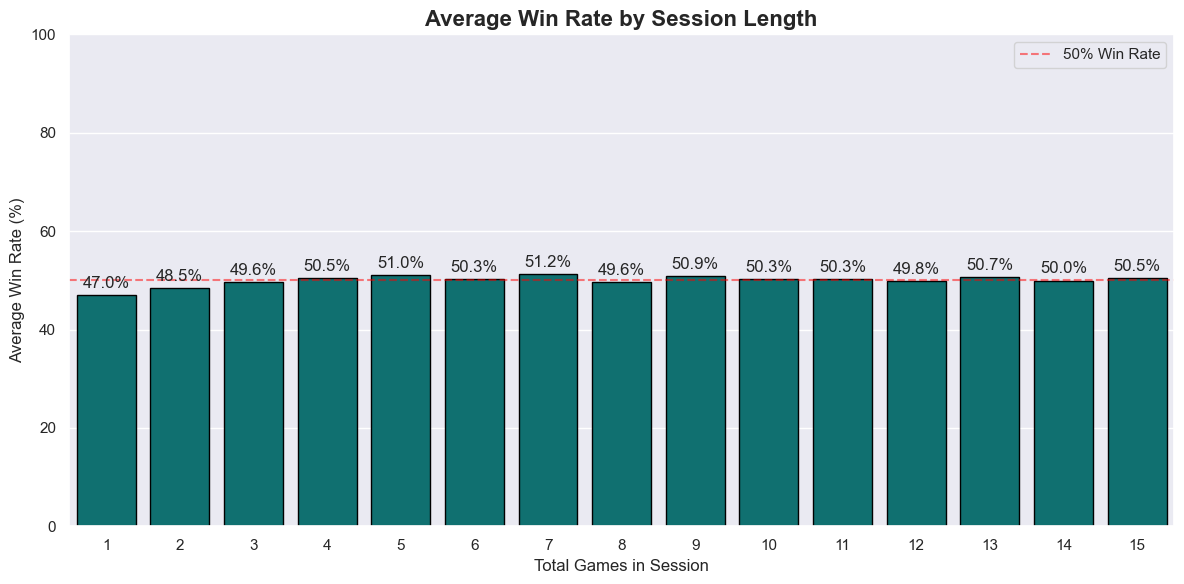

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="darkgrid")

# Filter out the extremely rare marathon sessions (e.g., 15+ games) so the graph is readable
plot_data = final_df[final_df['session_length'] <= 15]

plt.figure(figsize=(12, 6))

# Create the Bar Chart
# By default, sns.barplot calculates the MEAN of 'winrate' for each 'session_length'
ax = sns.barplot(
    data=plot_data, 
    x='session_length', 
    y='winrate', 
    color='teal', 
    edgecolor='black',
    errorbar=None  # Turns off the little error lines on top of the bars to keep it clean
)

# Add titles and labels
plt.title("Average Win Rate by Session Length", fontsize=16, fontweight='bold')
plt.xlabel("Total Games in Session", fontsize=12)
plt.ylabel("Average Win Rate (%)", fontsize=12)

# Add a dashed line at 50% for easy visual reference
plt.axhline(50, color='red', linestyle='--', alpha=0.5, label='50% Win Rate')
plt.legend()

# Add the exact percentages on top of each bar for easy reading
for i in ax.containers:
    ax.bar_label(i, fmt='%.1f%%', padding=3)

# Force the Y-axis to go up to 100% so the scale makes sense
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

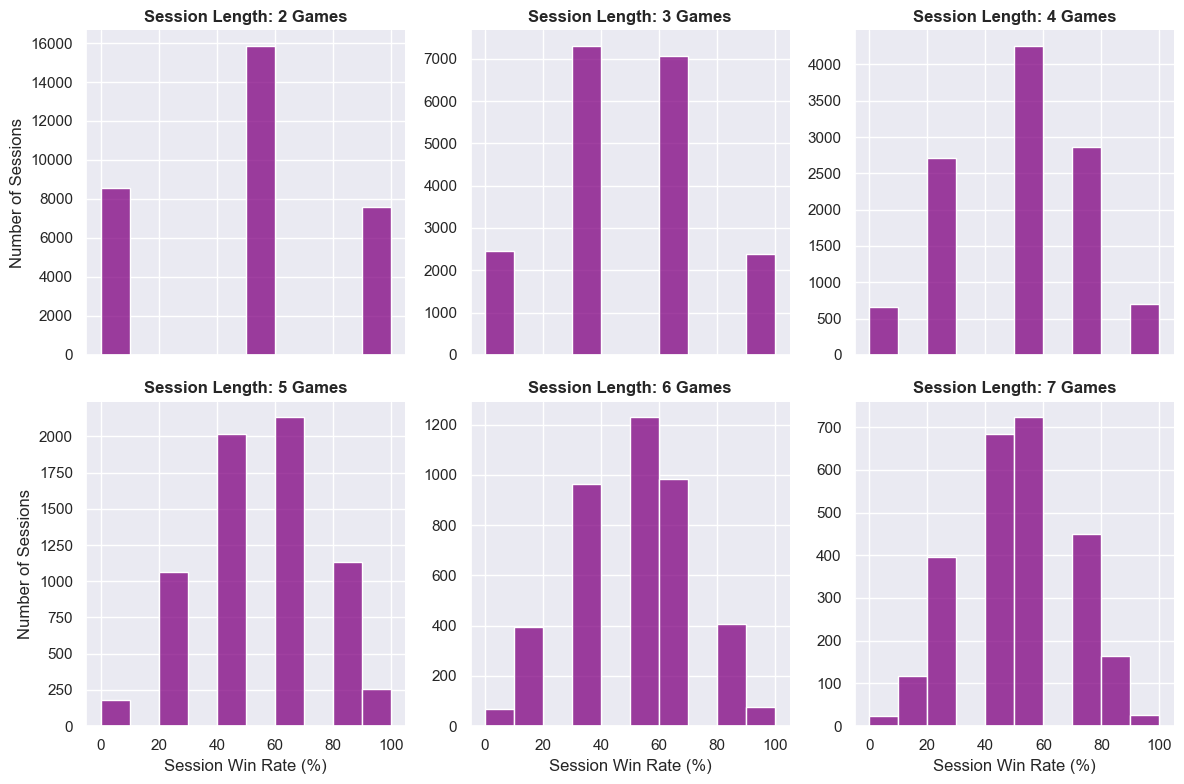

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

# Filter to session lengths 2 through 7 (1-game sessions are boring, they are just 0% or 100%)
plot_data = final_df[(final_df['session_length'] >= 2) & (final_df['session_length'] <= 7)]

# Create a grid of plots, one for each session length
g = sns.FacetGrid(plot_data, col="session_length", col_wrap=3, height=4, sharey=False)

# Map a histogram to every single plot in the grid
g.map(sns.histplot, "winrate", bins=10, color="purple", kde=False)

# Format the titles and labels
g.set_axis_labels("Session Win Rate (%)", "Number of Sessions")
g.set_titles(col_template="Session Length: {col_name} Games", size=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

session_lenght = 54

# Set the visual style
sns.set_theme(style="darkgrid")

# Filter out the extremely rare 15+ game marathon sessions so they don't squash the graph
plot_data = final_df[final_df['session_length'] <= session_lenght]

plt.figure(figsize=(12, 6))

# regplot creates a scatter plot AND automatically calculates/draws the trendline!
sns.regplot(
    data=plot_data, 
    x='session_length', 
    y='winrate', 
    scatter_kws={'alpha': 0.1, 'color': 'teal'}, # Make dots mostly transparent because there are so many
    line_kws={'color': 'red', 'linewidth': 3}    # Make the trendline thick and red
)

plt.title("Session Length vs. Overall Win Rate", fontsize=16, fontweight='bold')
plt.xlabel("Total Games in Session", fontsize=12)
plt.ylabel("Session Win Rate (%)", fontsize=12)

# Force the X-axis to show whole numbers (1, 2, 3...)
plt.xticks(range(1, session_lenght))

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))

# Create the boxplot
sns.boxplot(
    data=plot_data, 
    x='session_length', 
    y='winrate', 
    palette='viridis' # A nice color gradient
)

plt.title("Distribution of Win Rates by Session Length", fontsize=16, fontweight='bold')
plt.xlabel("Total Games in Session", fontsize=12)
plt.ylabel("Session Win Rate (%)", fontsize=12)

plt.tight_layout()
plt.show()

0. Fixing Timestamps and Recalculating Sessions...
1. Preparing Survival Data...
2. Calculating Rage Quit Metrics...
3. Plotting the Rage Quit Curve...


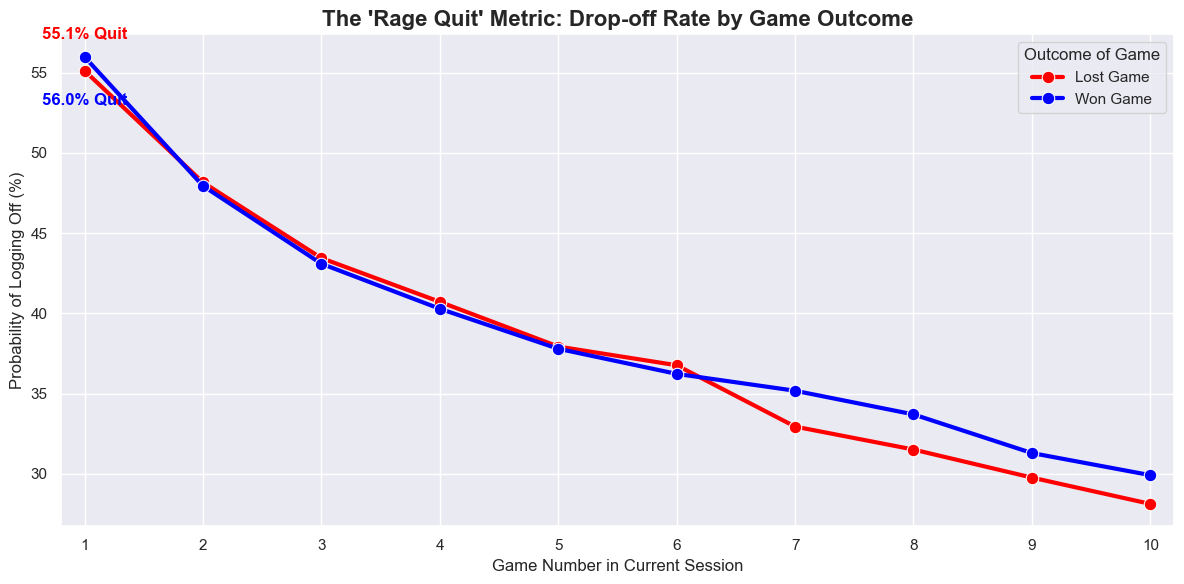

,game_number_in_session,win,quit_rate,player_count,Outcome of Game
0,1,0,55.118526,153257,Lost Game
1,1,1,55.980749,158124,Won Game
2,2,0,48.160189,68594,Lost Game
3,2,1,47.944695,69795,Won Game
4,3,0,43.446119,35170,Lost Game
5,3,1,43.092508,36721,Won Game
6,4,0,40.719526,19902,Lost Game
7,4,1,40.287288,20885,Won Game
8,5,0,37.933648,11876,Lost Game
9,5,1,37.795530,12393,Won Game


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set visual style
sns.set_theme(style="darkgrid")

print("0. Fixing Timestamps and Recalculating Sessions...")
# Load your backup data
df_usable = pd.read_csv("Data/Downloaded/usable_formatted_match_records.csv")

# THE FIX: If game_end_timestamp is missing, calculate it manually: Start Time + (Duration * 1000ms)
if df_usable['game_end_timestamp'].isna().any() or df_usable['game_end_timestamp'].isnull().all():
    print("   -> Missing end timestamps detected. Repairing using game duration...")
    df_usable['game_end_timestamp'] = df_usable['game_end_timestamp'].fillna(
        df_usable['game_start_timestamp'] + (df_usable['game_duration_sec'] * 1000)
    )

# Ensure 'win' is strictly numeric (1 and 0) to prevent True/False mapping bugs
df_usable['win'] = df_usable['win'].astype(int)

# Recalculate session time-gaps safely
df_usable = df_usable.sort_values(by=['puuid', 'game_start_timestamp'])
df_usable['prev_game_end'] = df_usable.groupby('puuid')['game_end_timestamp'].shift(1)
df_usable['time_since_last_game_ms'] = df_usable['game_start_timestamp'] - df_usable['prev_game_end']

SESSION_THRESHOLD_MS = 2 * 60 * 60 * 1000 
# Mark new sessions (Added safety: If gap is negative due to overlapping data, treat as new session)
df_usable['is_new_session'] = (df_usable['time_since_last_game_ms'] > SESSION_THRESHOLD_MS) | (df_usable['time_since_last_game_ms'].isna()) | (df_usable['time_since_last_game_ms'] < 0)
df_usable['session_id'] = df_usable.groupby('puuid')['is_new_session'].cumsum()
df_usable['game_number_in_session'] = df_usable.groupby(['puuid', 'session_id']).cumcount() + 1


# ==========================================
# 1. PREPARING SURVIVAL DATA
# ==========================================
print("1. Preparing Survival Data...")
df_usable['session_length'] = df_usable.groupby(['puuid', 'session_id'])['game_number_in_session'].transform('max')
df_usable['quit_after_game'] = (df_usable['game_number_in_session'] == df_usable['session_length']).astype(int)


# ==========================================
# 2. CALCULATING RAGE QUIT METRICS
# ==========================================
print("2. Calculating Rage Quit Metrics...")
survival_stats = df_usable.groupby(['game_number_in_session', 'win']).agg(
    quit_rate=('quit_after_game', 'mean'),
    player_count=('quit_after_game', 'count')
).reset_index()

# Filter out extreme session lengths
survival_stats = survival_stats[(survival_stats['game_number_in_session'] <= 10) & (survival_stats['player_count'] >= 100)]
survival_stats['quit_rate'] = survival_stats['quit_rate'] * 100
survival_stats['Outcome of Game'] = survival_stats['win'].map({1: 'Won Game', 0: 'Lost Game'})


# ==========================================
# 3. PLOTTING THE GRAPH
# ==========================================
print("3. Plotting the Rage Quit Curve...")
max_game = survival_stats['game_number_in_session'].max()

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=survival_stats,
    x='game_number_in_session',
    y='quit_rate',
    hue='Outcome of Game',
    palette={'Won Game': 'blue', 'Lost Game': 'red'}, 
    marker='o',
    linewidth=3,
    markersize=9
)

plt.title("The 'Rage Quit' Metric: Drop-off Rate by Game Outcome", fontsize=16, fontweight='bold')
plt.xlabel("Game Number in Current Session", fontsize=12)
plt.ylabel("Probability of Logging Off (%)", fontsize=12)

# THE GRAPH FIX: Force the X-axis to stay wide, even if the data acts up
if pd.isna(max_game) or max_game < 2:
    print("⚠️ WARNING: Data is still struggling to form sessions. Displaying default width.")
    plt.xlim(0.5, 5.5)
    plt.xticks([1, 2, 3, 4, 5])
else:
    plt.xlim(0.8, max_game + 0.2)
    plt.xticks(range(1, int(max_game) + 1))

# Safely annotate the exact percentages
try:
    game_1_loss = survival_stats[(survival_stats['game_number_in_session'] == 1) & (survival_stats['win'] == 0)]['quit_rate'].values[0]
    game_1_win = survival_stats[(survival_stats['game_number_in_session'] == 1) & (survival_stats['win'] == 1)]['quit_rate'].values[0]

    plt.text(1, game_1_loss + 2, f"{game_1_loss:.1f}% Quit", color='red', fontweight='bold', ha='center')
    plt.text(1, game_1_win - 3, f"{game_1_win:.1f}% Quit", color='blue', fontweight='bold', ha='center')
except IndexError:
    pass

plt.tight_layout()
plt.show()

# Display the raw stats table to ensure games 2+ exist
display(survival_stats.head(10))